# Learning the control: optimizing a linear feedback control


This notebook demonstrates how to optimize a simple feedback control by computing gradients through `DiscreteControlLoopSimulator`
We use:
1. a simple 1D linear-Gaussian dynamical system (a noisy random walk, `x_{k+1} = A x_k + B u_k + noise`) with the full state directly observed under Gaussian noise,
2. a linear feedback policy `u_k = -K x_hat_k` that drives the state toward 0,
3. a plot comparing the controlled trajectory against an uncontrolled (`K=0`) baseline.

In [1]:
import equinox as eqx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.handlers import seed

import dynestyx as dsx
from dynestyx.control.discrete_controller_simulators import DiscreteControlLoopSimulator, filter_state_mean
from dynestyx.inference.configs.filter import KFConfig
from dynestyx.models import DynamicalModel
from dynestyx.models.observations import LinearGaussianObservation
from dynestyx.models.state_evolution import LinearGaussianStateEvolution


import jax
import optax
from optax import sgd, adam

## 1. Define the dynamics

`state_dim = control_dim = observation_dim = 1`. The transition is `x_{k+1} = A x_k + B u_k + noise`, with `A = 1` -- a marginally-unstable random walk when uncontrolled, so the effect of feedback control is visually obvious. The observation model directly observes the full state under additive Gaussian noise (`H = I`, no control dependence).

In [2]:
state_dim = control_dim = obs_dim = 2

dynamics = DynamicalModel(
    initial_condition=dist.MultivariateNormal(jnp.array([0.0, 0.0]), 5.0 * jnp.eye(state_dim)),
    state_evolution=LinearGaussianStateEvolution(
        A=jnp.eye(state_dim), B=jnp.eye(control_dim), cov=0.05 * jnp.eye(state_dim)
    ),
    observation_model=LinearGaussianObservation(
        H=jnp.eye(obs_dim, state_dim), R=0.2 * jnp.eye(obs_dim)
    ),
    control_dim=control_dim,
)

## 2. Define the controller

A simple linear feedback policy `u = -K x_hat`, implemented as an `equinox.Module`.

In [3]:
class LinearPolicy(eqx.Module):
    K: jnp.ndarray

    def __call__(self, x_hat, s, key):
        return -self.K @ filter_state_mean(x_hat), s

## 3. Differentiating through the closed loop

`DiscreteControlLoopSimulator` is pure JAX under the hood and so we can compute gradients.

In [4]:
predict_times_short = jnp.arange(0.0, 5.0)


def rollout_final_state_norm(K):
    policy = LinearPolicy(K=K)
    sim = DiscreteControlLoopSimulator(
        control_policy=policy,
        policy_state_init=None,
        filter_config=KFConfig(filter_source="cuthbert"),
    )

    def model():
        with sim:
            return dsx.sample("loop_grad", dynamics, predict_times=predict_times_short)

    with seed(rng_seed=0):
        tr = numpyro.handlers.trace(model).get_trace()

    final_state = tr["loop_grad_states"]["value"][0, -1, :]
    return jnp.linalg.norm(final_state)


K0 = jnp.eye(state_dim)*1e-2
loss_value = rollout_final_state_norm(K0)
grad_K = jax.grad(rollout_final_state_norm)(K0)
print("Initial loss value:", loss_value)
print("Gradient of loss w.r.t K:", grad_K)  

Initial loss value: 3.3988597
Gradient of loss w.r.t K: [[-9.146291  -2.3959942]
 [-2.051858  -0.5375118]]


In [5]:
# Finite-difference check for one entry of K (K[0, 0]) -- confirms the
# autodiff gradient through the whole closed loop (policy -> transition ->
# observation -> filter update) is correct, not just plausible-looking.
eps = 1e-3
K_plus = K0.at[0, 0].add(eps)
K_minus = K0.at[0, 0].add(-eps)
finite_diff = (rollout_final_state_norm(K_plus) - rollout_final_state_norm(K_minus)) / (2 * eps)

print(f"autodiff grad_K[0, 0]:       {grad_K[0, 0]:.6f}")
print(f"finite-difference estimate: {finite_diff:.6f}")
assert jnp.allclose(grad_K[0, 0], finite_diff, atol=1e-3)
print("OK: matches within tolerance")

autodiff grad_K[0, 0]:       -9.146291
finite-difference estimate: -9.146333
OK: matches within tolerance


# 4. Optimizing the controller

Here we optimize the control matrix $K$ by unrolling forward in time.

In [6]:
epochs = 100
learning_rate = 1e-2
losses = []

optimizer = adam(learning_rate)
K_opt = jnp.copy(K0)
optim_state = optimizer.init(K_opt)
for epoch in range(epochs):
    loss_value = rollout_final_state_norm(K_opt)
    grad_K = jax.grad(rollout_final_state_norm)(K_opt)

    updates, optim_state = optimizer.update(grad_K, optim_state)
    K_opt = optax.apply_updates(K_opt, updates)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss={loss_value:.4f}, K={K_opt}")
    losses.append(loss_value)   

Epoch 0: Loss=3.3989, K=[[0.01999993 0.00999993]
 [0.00999993 0.01999993]]


Epoch 10: Loss=2.4137, K=[[0.11847139 0.10515232]
 [0.07049416 0.08127257]]


Epoch 20: Loss=1.7742, K=[[0.20946947 0.1924458 ]
 [0.02874766 0.05257629]]


Epoch 30: Loss=1.3639, K=[[ 0.28581044  0.28569815]
 [-0.00282588  0.07741808]]


Epoch 40: Loss=1.0758, K=[[ 0.34550726  0.37999433]
 [-0.02754382  0.1624869 ]]


Epoch 50: Loss=0.8342, K=[[ 0.39051867  0.47120607]
 [-0.09727044  0.24462393]]


Epoch 60: Loss=0.5648, K=[[ 0.42187175  0.56293285]
 [-0.20241553  0.34037805]]


Epoch 70: Loss=0.1934, K=[[ 0.439474    0.6599499 ]
 [-0.342188    0.39983138]]


Epoch 80: Loss=0.1168, K=[[ 0.446912    0.7127304 ]
 [-0.4105265   0.41421664]]


Epoch 90: Loss=0.0685, K=[[ 0.45032692  0.6890083 ]
 [-0.35963085  0.39156887]]


Text(0, 0.5, 'Loss (||x_T||)')

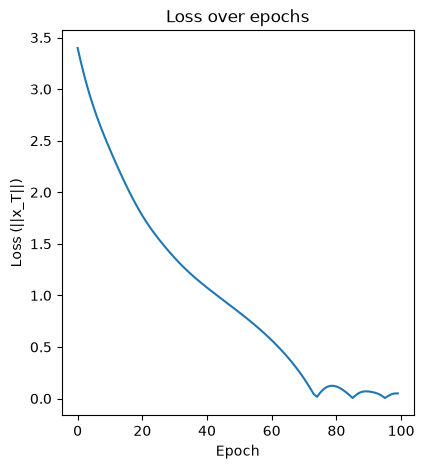

In [7]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (||x_T||)")    

In [8]:
# Now run the loop with both the initial and optimized K to compare resultspredict_times = jnp.arange(0.0, 30.0)

predict_times = jnp.arange(0.0, 30.0)
def run(K):
    policy = LinearPolicy(K=K)

    def model():
        with DiscreteControlLoopSimulator(
            control_policy=policy,
            policy_state_init=None,
            filter_config=KFConfig(record_filtered_states_mean=True),
        ):
            return dsx.sample("loop", dynamics, predict_times=predict_times)

    with seed(rng_seed=0):
        return numpyro.handlers.trace(model).get_trace()


trace_unopt = run(K0)
trace_opt = run(K_opt)

true_state shape: (30,)
obs shape: (30,)
filtered_mean shape: (30,)
true_state shape: (30,)
obs shape: (30,)
filtered_mean shape: (30,)


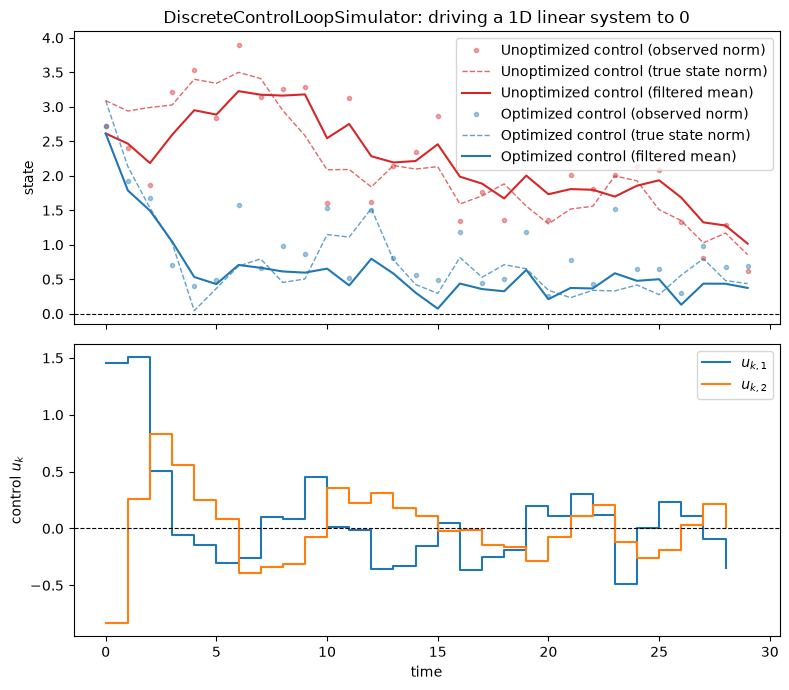

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

runs = [
    (trace_unopt, "Unoptimized control", "tab:red"),
    (trace_opt, "Optimized control", "tab:blue"),
]
for trace, label, color in runs:
    t = trace["loop_times"]["value"][0]
    true_state = jnp.linalg.norm(trace["loop_states"]["value"][0, :], axis=-1)
    print("true_state shape:", true_state.shape)
    obs = jnp.linalg.norm(trace["loop_observations"]["value"][0, :], axis=-1)
    print("obs shape:", obs.shape)
    filtered_mean = jnp.linalg.norm(trace["loop_filtered_states_mean"]["value"][0, :], axis=-1)
    print("filtered_mean shape:", filtered_mean.shape)
    axes[0].plot(t, obs, ".", color=color, alpha=0.4, label=f"{label} (observed norm)")
    axes[0].plot(t, true_state, "--", color=color, alpha=0.7, linewidth=1, label=f"{label} (true state norm)")
    axes[0].plot(t, filtered_mean, "-", color=color, label=f"{label} (filtered mean)")

axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("state")
axes[0].legend()
axes[0].set_title("DiscreteControlLoopSimulator: driving a 1D linear system to 0")

t_u = trace_opt["loop_times"]["value"][0][:-1]
u_1 = trace_opt["loop_controls"]["value"][0, :, 0]
u_2 = trace_opt["loop_controls"]["value"][0, :, 1]

axes[1].step(t_u, u_1, where="post", color="tab:blue", label="$u_{k,1}$")
axes[1].step(t_u, u_2, where="post", color="tab:orange", label="$u_{k,2}$")
axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].legend() 
axes[1].set_ylabel("control $u_k$")
axes[1].set_xlabel("time")

plt.tight_layout()
plt.show()